# ADIM 5 — RQ3: Maliyete duyarlı eşik + Kâr/ROI + EMP

Operasyonel model: **HAM/doğal-dağılım LightGBM** (Adım 2 best_params), kalibrasyon
katmanı YOK. Olasılıklar **5-kat out-of-fold** (model gördüğü müşteriyi puanlamaz —
sızıntı yok). Maliyet/değer için **sihirli sayı yok**: parametrik (c, γ, müşteri-başı
CLV) + duyarlılık. 5 set bağımsız; holdout girmez. Ağır mantık `src/profit.py`'de.

Kâr matrisi: TP=γ·CLV−c, FP=−c, FN=−CLV, TN=0 (standart cost-sensitive churn).
A = doğruluk-eşiği (t=0.5); B = kâr-maksimize eşik t*. EMP = setler-arası kıyas
(γ~Beta dağılımı üstünde kişi-başı beklenen maksimum kâr, ortalama CLV'ye normalize).

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd


def _bul_kok():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / "config.yaml").exists():
            return c
    raise RuntimeError("config.yaml bulunamadı")


KOK = _bul_kok()
if str(KOK) not in sys.path:
    sys.path.insert(0, str(KOK))

warnings.filterwarnings("ignore")
from src import config as cfg
from src import plotstyle as ps
from src import profit as pr
from src import strings_tr as S

np.random.seed(cfg.SEED)
ps.uygula()
cfg.klasorleri_hazirla()
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 120)

CIKTI = []


def yaz(s=""):
    print(s)
    CIKTI.append(str(s))

## 1. CLV temelleri (config'te tanımlı; sihirli sayı yok, hepsi loglanır)

In [2]:
veriler = {k: pd.read_csv(cfg.PROCESSED / f"{k}_clean.csv") for k in cfg.DATASETS}
a, b = pr.PARAM["emp_beta"]
yaz(S.MSG5["emp_varsayim"].format(a=a, b=b, e=a / (a + b), c=int(pr.PARAM["emp_c_oran"] * 100)))
yaz(f"Parametreler: ufuk={pr.PARAM['ufuk_ay']} ay | c oranları={pr.PARAM['c_oranlari']} | γ={pr.PARAM['gamma_listesi']}")

EMP varsayımı: γ ~ Beta(6,14) (E[γ]=0.30), referans maliyet=ort_CLV'nin %5'si.
Parametreler: ufuk=24 ay | c oranları=[0.01, 0.02, 0.05, 0.1, 0.2] | γ=[0.2, 0.3, 0.4, 0.5]


## 2. Her set: OOF olasılık + (c,γ) taraması + kâr-eşiği + ROI + EMP
**(En uzun adım: set başına bir 5-kat CV.)**

In [3]:
yaz(S.MSG["bolum"].format(ad="KÂR / ROI / EMP HESABI"))
tum = {}
for k in cfg.DATASETS:
    t = time.time()
    tum[k] = pr.calistir_set(k, veriler[k], cfg.SEED)
    r = tum[k]
    yaz(S.MSG5["clv"].format(set=k, temel=r["temel"], ort=r["ort_clv"], medyan=r["medyan_clv"], sifir=r["sifir"]))
    yaz(f"  EMP(kişi başı, ort-CLV birimi)={r['emp']:.4f}  ({time.time()-t:.0f}s)")

===== KÂR / ROI / EMP HESABI =====


telco: CLV temeli = MonthlyCharges × 24 ay; ort=1554.3 medyan=1688.4 (sıfır CLV: 0)
  EMP(kişi başı, ort-CLV birimi)=0.0491  (4s)


cell2cell: CLV temeli = MonthlyRevenue × 24 ay; ort=1411.3 medyan=1163.0 (sıfır CLV: 9)
  EMP(kişi başı, ort-CLV birimi)=0.0352  (18s)


ecommerce: CLV temeli = CashbackAmount (aylık değer proxy) × 24 ay; ort=4241.0 medyan=3920.2 (sıfır CLV: 3)
  EMP(kişi başı, ort-CLV birimi)=0.0162  (14s)


iranian: CLV temeli = Customer Value (doğrudan); ort=471.0 medyan=228.5 (sıfır CLV: 132)
  EMP(kişi başı, ort-CLV birimi)=0.0007  (16s)


bank: CLV temeli = Balance × 0.02 yıllık marj × 2.0 yıl; ort=3059.4 medyan=3887.9 (sıfır CLV: 3617)
  EMP(kişi başı, ort-CLV birimi)=0.0319  (4s)


## 3. Tablolar
`rq3_profit_summary.csv` (set × c × γ: eşik A/B, kâr A/B, ROI A/B, ROI artışı, EMP)
ve `rq3_clv_basis.csv`.

In [4]:
ozet = pr.tablo_ozet(tum)
clv_t = pr.tablo_clv(tum)
yaz(S.MSG["bolum"].format(ad="CLV TEMELLERİ"))
yaz(clv_t.to_string(index=False))
yaz(S.MSG["bolum"].format(ad="KÂR/ROI ÖZET (tüm c,γ)"))
yaz(ozet.to_string(index=False))
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "rq3_profit_summary.csv"))
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "rq3_clv_basis.csv"))

===== CLV TEMELLERİ =====
Veri Seti                                 CLV temeli  Ortalama CLV  Medyan CLV  Sıfır CLV sayısı
    telco                     MonthlyCharges × 24 ay       1554.28     1688.40                 0
cell2cell                     MonthlyRevenue × 24 ay       1411.27     1163.04                 9
ecommerce CashbackAmount (aylık değer proxy) × 24 ay       4240.98     3920.16                 3
  iranian                  Customer Value (doğrudan)        470.97      228.48               132
     bank       Balance × 0.02 yıllık marj × 2.0 yıl       3059.44     3887.94              3617
===== KÂR/ROI ÖZET (tüm c,γ) =====
Veri Seti  Maliyet oranı   γ  Eşik A (0.5)  Eşik B (t*)       Kâr A      Kâr B    ROI A  ROI B  ROI artışı (B−A)  Kâr artışı %  EMP (kişi başı)
    telco           0.01 0.2           0.5         0.01  -1144102.8   558671.0  -50.695  5.118            55.813         148.8           0.0491
    telco           0.01 0.3           0.5         0.01   -959302.3  

## 4. Figürler
`outputs/figures/<set>/`: rq3_profit_vs_threshold, rq3_roi_sensitivity, rq3_strategy_comparison.
`outputs/figures/_rq3/`: rq3_emp_by_dataset.

===== FİGÜRLER =====


telco: 3 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/telco


cell2cell: 3 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/cell2cell


ecommerce: 3 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/ecommerce


iranian: 3 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/iranian


bank: 3 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/bank
Kaydedildi: /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/_rq3/rq3_emp_by_dataset.png


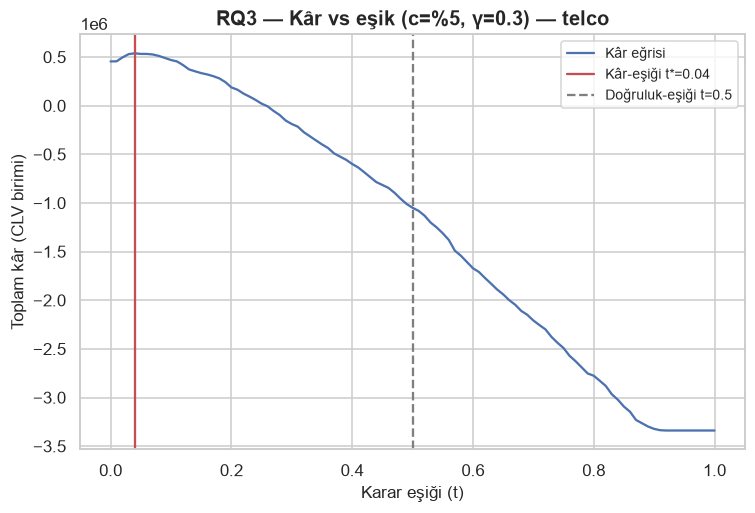

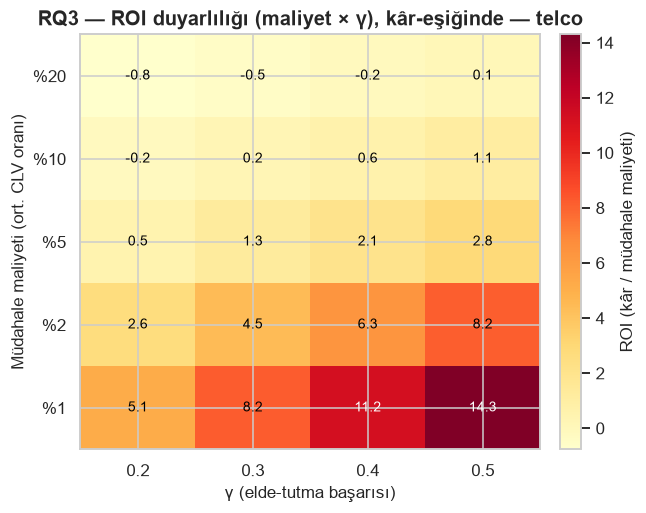

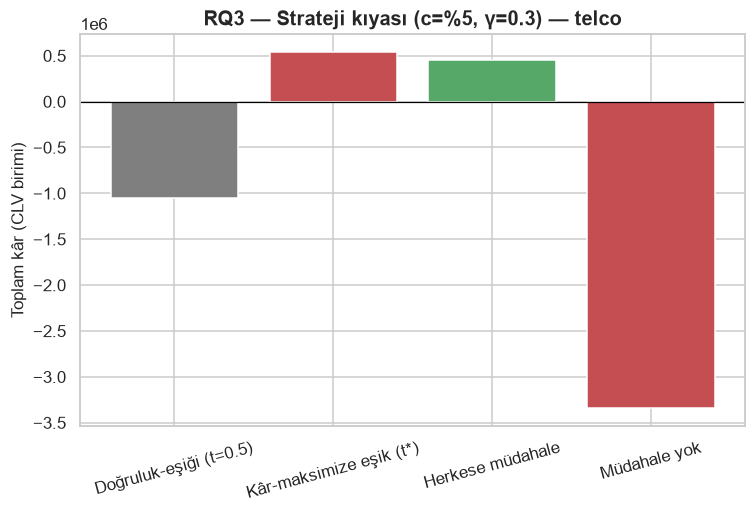

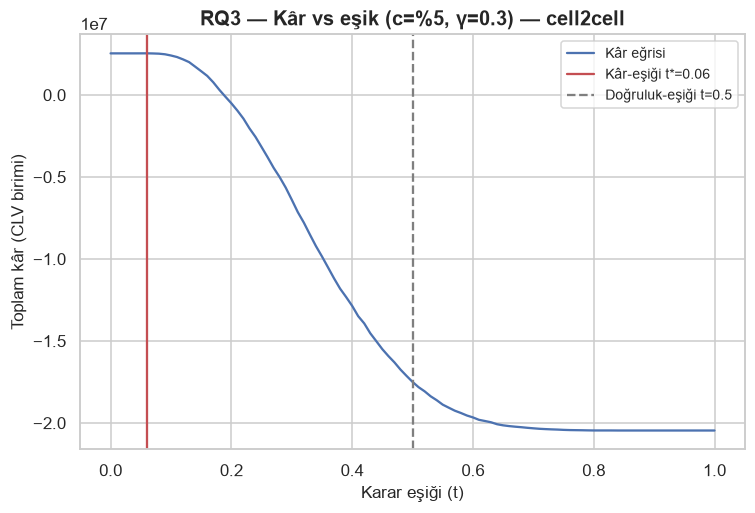

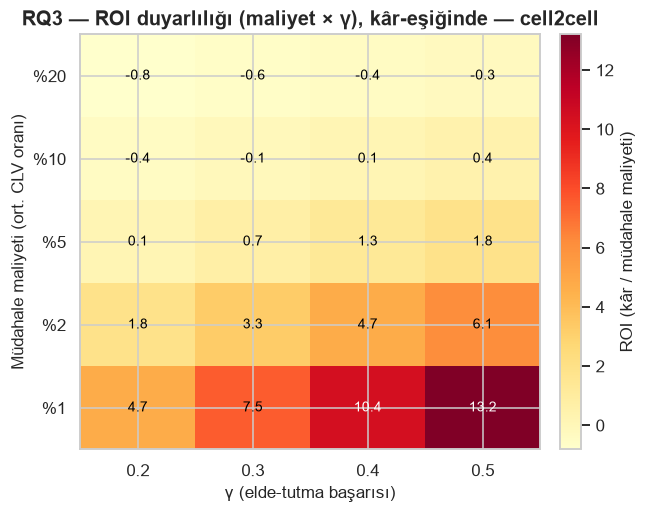

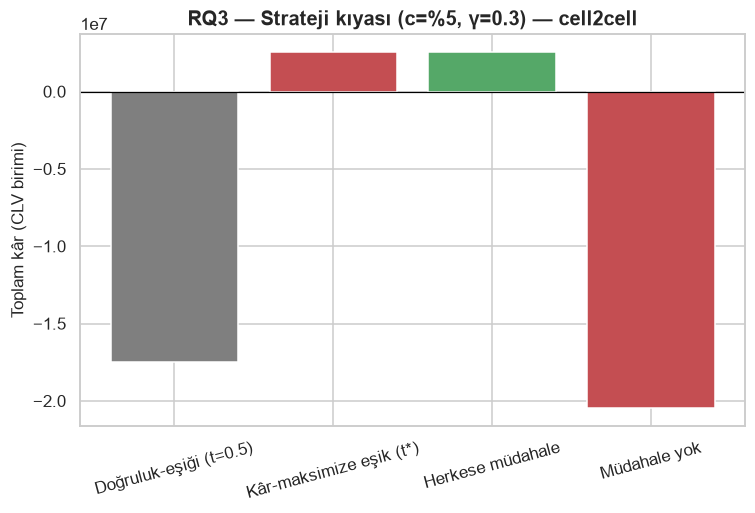

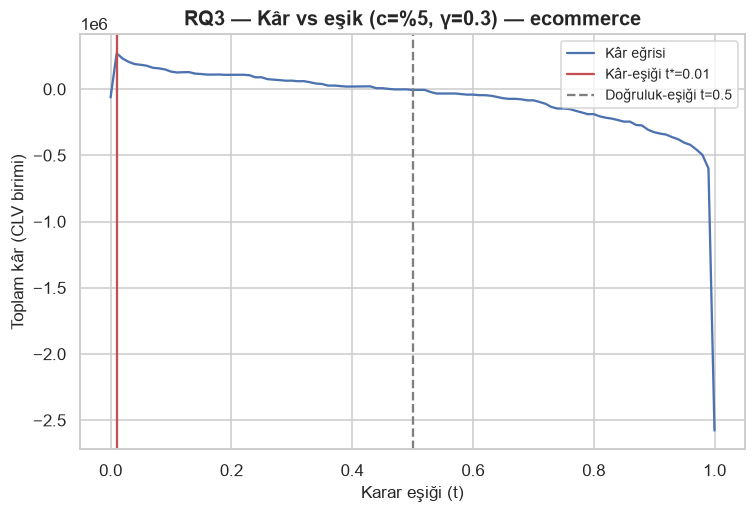

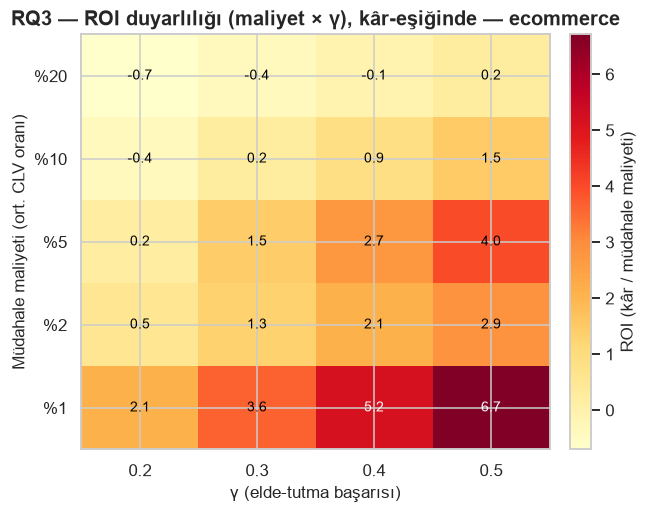

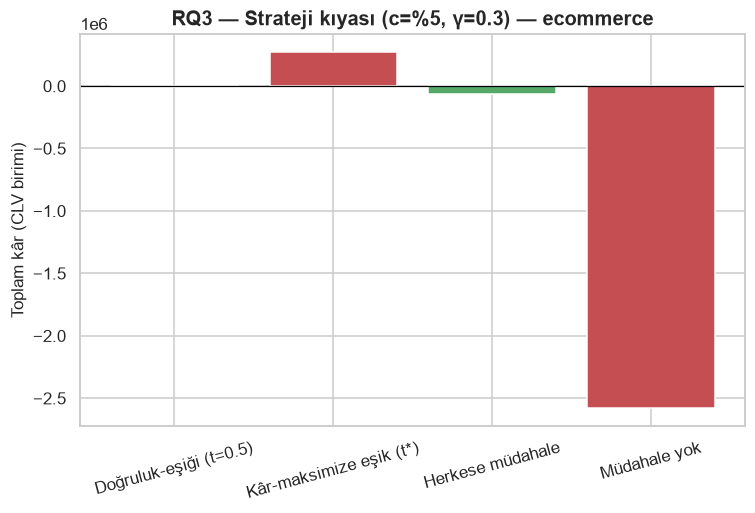

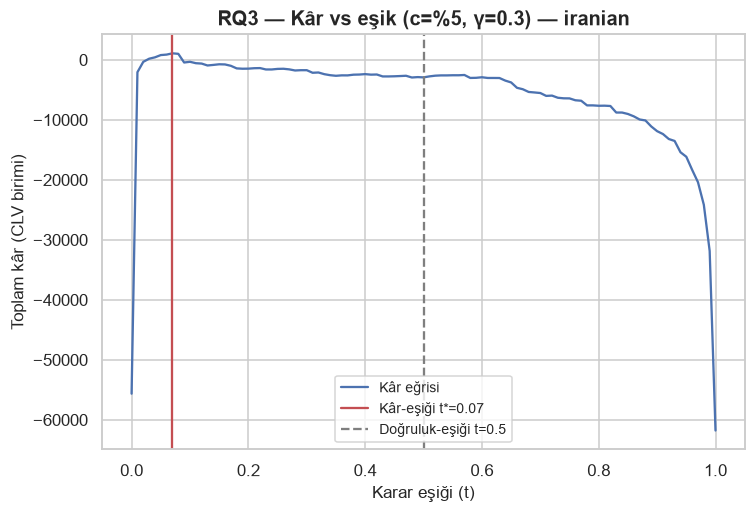

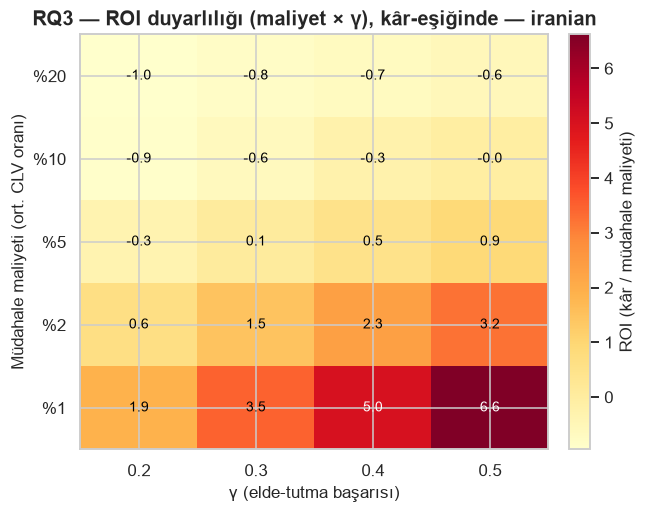

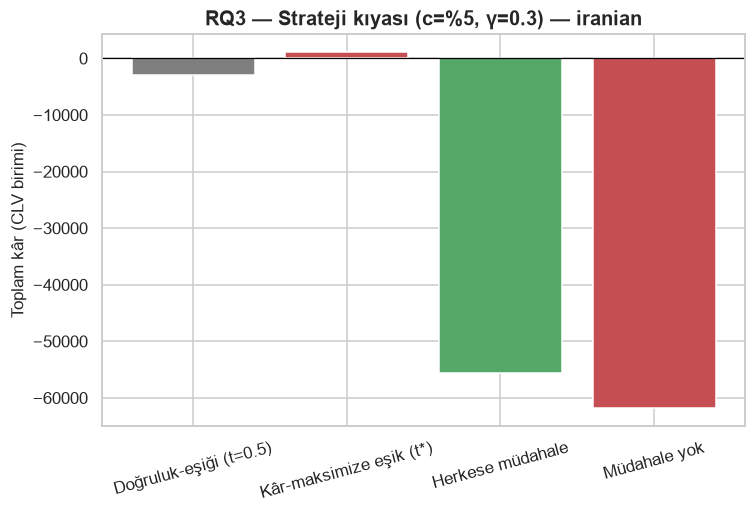

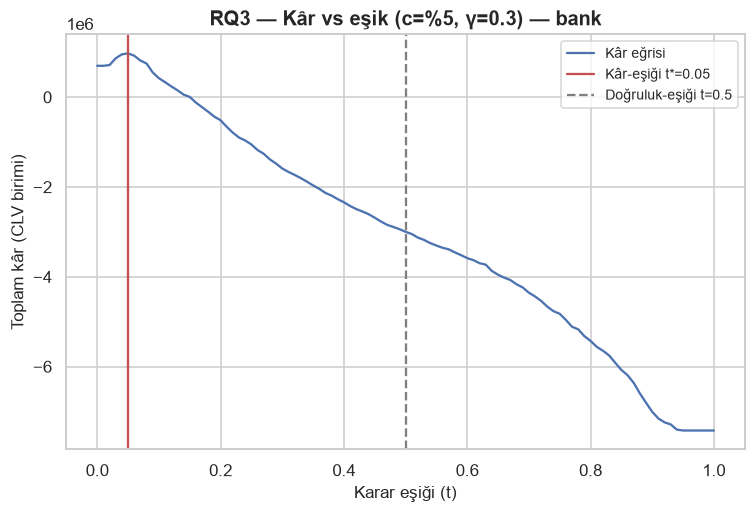

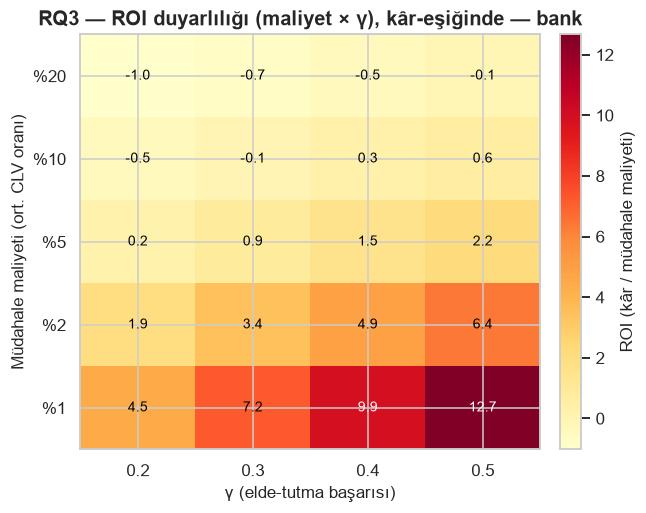

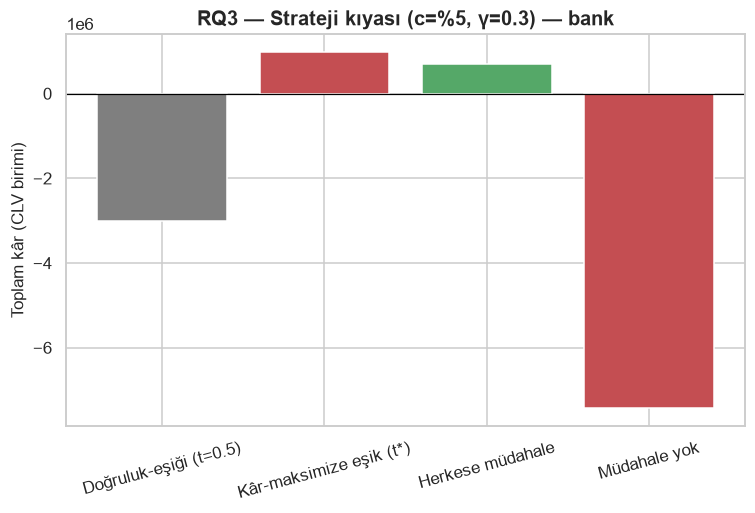

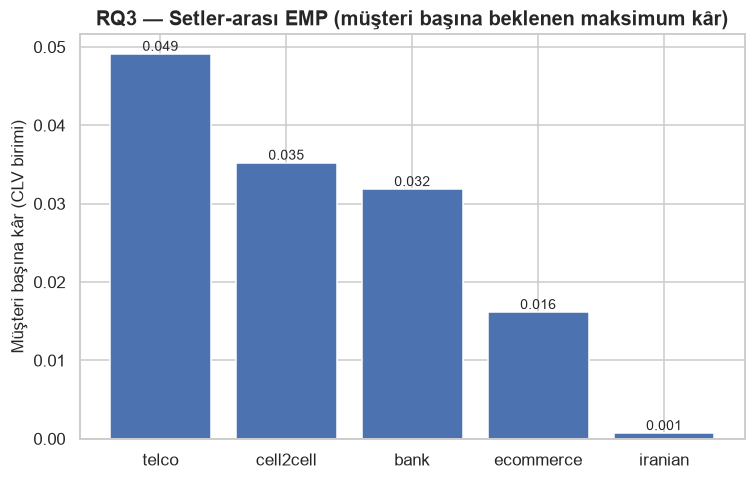

In [5]:
yaz(S.MSG["bolum"].format(ad="FİGÜRLER"))
for k in cfg.DATASETS:
    yollar = pr.figurler_set(k, tum[k])
    yaz(f"{k}: {len(yollar)} figür -> {cfg.FIGURES / k}")
yol_emp = pr.figur_emp(tum)
yaz(S.MSG["kayit"].format(yol=yol_emp))

## 5. Özet — RQ3 manşeti (karar kullanıcıda)
Kâr-eşiğinin (B) doğruluk-eşiğine (A) göre ROI/kâr kazancı, EMP sıralaması,
parametre duyarlılığı (işaret yön değiştiriyor mu).

In [6]:
yaz(S.MSG["bolum"].format(ad="ÖZET — RQ3"))
K = S.KOLON5
for k in cfg.DATASETS:
    sub = ozet[ozet[K["veri_seti"]] == k]
    ra = sub[K["roi_artis"]]
    kp = sub[K["kar_artis_yuzde"]]
    yaz(S.MSG5["set_ozet"].format(
        set=k,
        dusuk=f"ROI+{ra.min():.2f}/kâr+{kp.min():.0f}%",
        yuksek=f"ROI+{ra.max():.2f}/kâr+{kp.max():.0f}%",
        emp=tum[k]["emp"]))
    neg = int((sub[K["kar_b"]] < sub[K["kar_a"]]).sum())
    yaz(f"    B<A olan (c,γ) sayısı: {neg}/{len(sub)} (0 ise kâr-eşiği her senaryoda en az A kadar)")

emp_sirali = sorted(cfg.DATASETS, key=lambda s: tum[s]["emp"], reverse=True)
yaz("")
yaz(S.MSG5["emp_sira"].format(sira=" > ".join(f"{s}({tum[s]['emp']:.3f})" for s in emp_sirali)))
en_kazandiran = max(cfg.DATASETS, key=lambda s: ozet[ozet[K["veri_seti"]] == s][K["kar_artis_yuzde"]].median())
yaz(f"Kâr-eşiğinin en çok kazandırdığı set (medyan kâr artışı %): {en_kazandiran}")
yaz("")
yaz(S.MSG5["bitti"])

_log = cfg.LOGS / "adim5_ozet.log"
_log.write_text("\n".join(CIKTI) + "\n", encoding="utf-8")
print(S.MSG["kayit"].format(yol=_log))

===== ÖZET — RQ3 =====
telco: kâr-eşiği ROI artışı aralığı (c,γ taraması): ROI+2.33/kâr+47% … ROI+55.81/kâr+365%; EMP=0.0491
    B<A olan (c,γ) sayısı: 0/20 (0 ise kâr-eşiği her senaryoda en az A kadar)
cell2cell: kâr-eşiği ROI artışı aralığı (c,γ taraması): ROI+18.97/kâr+48% … ROI+386.78/kâr+156%; EMP=0.0352
    B<A olan (c,γ) sayısı: 0/20 (0 ise kâr-eşiği her senaryoda en az A kadar)
ecommerce: kâr-eşiği ROI artışı aralığı (c,γ taraması): ROI+-12.73/kâr+15% … ROI+6.15/kâr+4542%; EMP=0.0162
    B<A olan (c,γ) sayısı: 0/20 (0 ise kâr-eşiği her senaryoda en az A kadar)
iranian: kâr-eşiği ROI artışı aralığı (c,γ taraması): ROI+-0.91/kâr+5% … ROI+1.62/kâr+1145%; EMP=0.0007
    B<A olan (c,γ) sayısı: 0/20 (0 ise kâr-eşiği her senaryoda en az A kadar)
bank: kâr-eşiği ROI artışı aralığı (c,γ taraması): ROI+3.52/kâr+42% … ROI+85.58/kâr+261%; EMP=0.0319
    B<A olan (c,γ) sayısı: 0/20 (0 ise kâr-eşiği her senaryoda en az A kadar)

EMP sıralaması (yüksek->düşük): telco(0.049) > cell2cell(0.035)